<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td  style="border: none!important;">
        <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                <h1 align=center><font size=5 color="#87CEEB"> <b>Introduction to Cognitive Science</b><br><br>HomeWork #2</i></font></h1>
            </td>
            <td style="border: none!important;">
        <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
            </td>
        </tr>
        </table>
    
</div>
<br>
<font size=3 color="#00FFFF"> Sina Pirmoradian : 810101125 <br></font><br>

<font color="#FA5F55"><h1>HW #2 Part #1</h2></font>

<font color="#F4BB44"><h3>Connect Google Drive</h3></font>

In [1]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


<font color="#F4BB44"><h3>Import Reqiured Library</h3></font>

In [2]:
import numpy as np
from scipy import signal
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

<font color="#F4BB44"><h3>Loading Data</h3></font>

In [3]:
# Load the data from the .mat file
data = sio.loadmat('/content/drive/MyDrive/Cognetive/HW_2/extracellular.mat')

spike = sio.loadmat('/content/drive/MyDrive/Cognetive/HW_2/spikes.mat')
spike_idx = spike['SpikeInds'][0]

<font color="#F4BB44"><h3>Extracextract the Voltage Amplitude</h3></font>

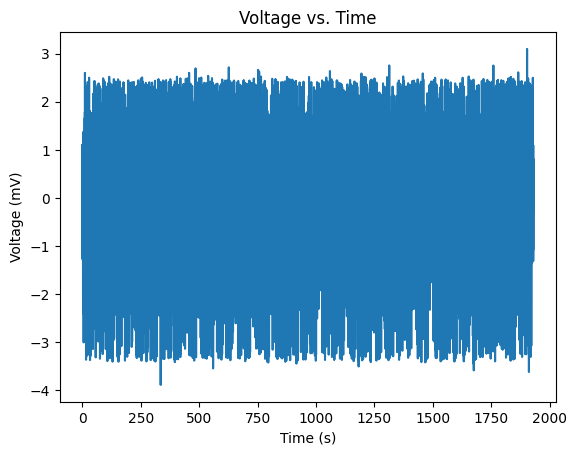

In [4]:
# extract the voltage amplitude data from the structure
voltage = data['all_data_with_noise_and_line'][0,:] 

# Sampling rate of the recording is 2400Hz
sampling_rate = 2400

# Create a time axis based on the sampling rate of 2400Hz
sampling_rate = 2400
time = np.arange(len(voltage)) / sampling_rate

# Plot the voltage against time
plt.plot(time, voltage)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Voltage vs. Time')
plt.show()


<font color="#F4BB44"><h3>Plot the voltage and  against time in a wide shape</h3></font>

Text(0, 0.5, 'amplitude')

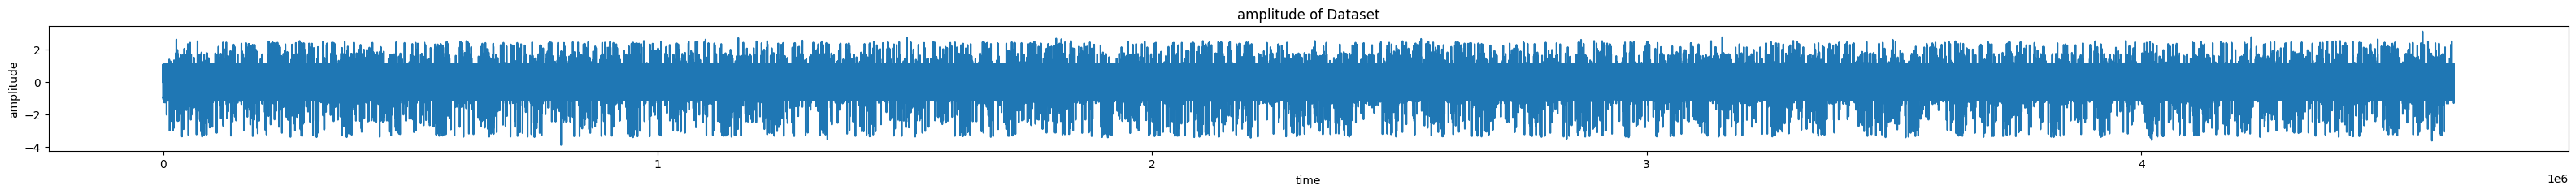

In [6]:
# Plot the voltage against time
plt.figure(figsize=(40,2))
plt.plot(voltage)
plt.title('amplitude of Dataset')
plt.xlabel('time')
plt.ylabel('amplitude')

<font color="#F4BB44"><h3>Plot the histogram of the voltage amplitudes</h3></font>


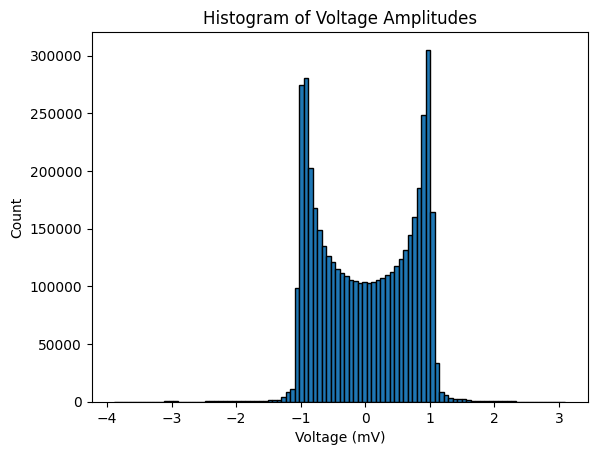

In [7]:
# Flatten the voltage array to a 1D array
voltage_flat = voltage.flatten()

# Plot the histogram of the voltage amplitudes
plt.hist(voltage_flat, bins=100, edgecolor='black')
plt.xlabel('Voltage (mV)')
plt.ylabel('Count')
plt.title('Histogram of Voltage Amplitudes')
plt.show()

<font color="#F4BB44"><h3>Plot Unfiltered vs. Filtered Data Together</h3></font>


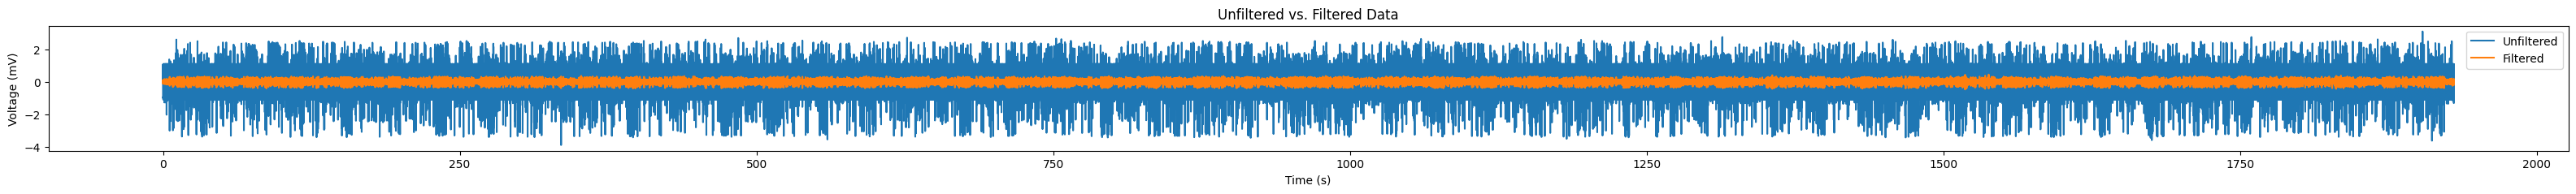

In [8]:
# Define filter parameters
highpass_freq = 300
filter_order = 7

# Calculate the Nyquist frequency
nyquist_freq = sampling_rate / 2

# Calculate the highpass cutoff frequency as a fraction of the Nyquist frequency
highpass_cutoff = highpass_freq / nyquist_freq

# Design the highpass Butterworth filter
b, a = signal.butter(filter_order, highpass_cutoff, btype='highpass')

# Apply the filter to the data using the filtfilt function
filtered_voltage = signal.filtfilt(b, a, voltage)

# Create a time axis based on the number of samples and sampling rate
time = np.arange(len(voltage)) / sampling_rate

plt.figure(figsize=(40,2))
# Plot the unfiltered data
plt.plot(time, voltage, label='Unfiltered')
# Plot the filtered data
plt.plot(time, filtered_voltage, label='Filtered')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Unfiltered vs. Filtered Data')
plt.legend()
plt.show()


<font color="#F4BB44"><h3>Filtering: Applying a Bandpass Filter</h3></font>

Voltage Threshold (θ): 0.2165574093077027


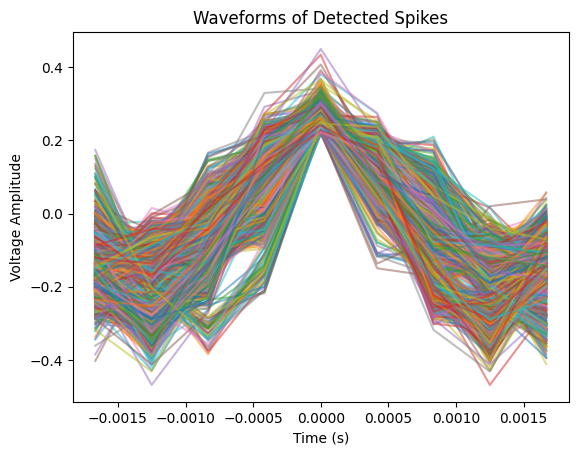

In [9]:
# extract the voltage amplitude data from the structure
voltage = data['all_data_with_noise_and_line'][0,:] 

# Define filter parameters
fs = 2400  # Sampling rate
highpass_freq = 300
filter_order = 7

# Calculate the Nyquist frequency
sampling_rate = 2400
nyquist_freq = sampling_rate / 2

# Calculate the highpass cutoff frequency as a fraction of the Nyquist frequency
highpass_cutoff = highpass_freq / nyquist_freq

# Design the highpass Butterworth filter
b, a = signal.butter(filter_order, highpass_cutoff, btype='highpass')

# Apply the filter to the data using the filtfilt function
filtered_voltage = signal.filtfilt(b, a, voltage)

# Calculate the voltage threshold (θ)
sigma_n = np.median(np.abs(filtered_voltage)) / 0.6745
threshold = 5 * sigma_n

print("Voltage Threshold (θ):", threshold)

# Extract peaks in the data
peaks, _ = find_peaks(filtered_voltage, height=0)  # Find peaks with positive height

# Select points above the threshold
spike_points = peaks[filtered_voltage[peaks] >= threshold]

# Define the time window for waveform extraction
window_size = int(fs * 0.002)  # 2ms before and after the peak
time_window = np.arange(-window_size, window_size + 1) / fs

# Extract waveforms for each detected spike
waveforms = []
for point in spike_points:
    waveform = filtered_voltage[point - window_size: point + window_size + 1]
    waveforms.append(waveform)

waveforms = np.array(waveforms)

# Plot the waveforms for each detected spike
plt.figure()
for waveform in waveforms:
    plt.plot(time_window, waveform, alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('Voltage Amplitude')
plt.title('Waveforms of Detected Spikes')
plt.show()

# Store the waveforms in a 2D matrix for the next step
# waveforms is the 2D matrix containing the waveforms


<font color="#F4BB44"><h3>Spike Detection</h3></font>

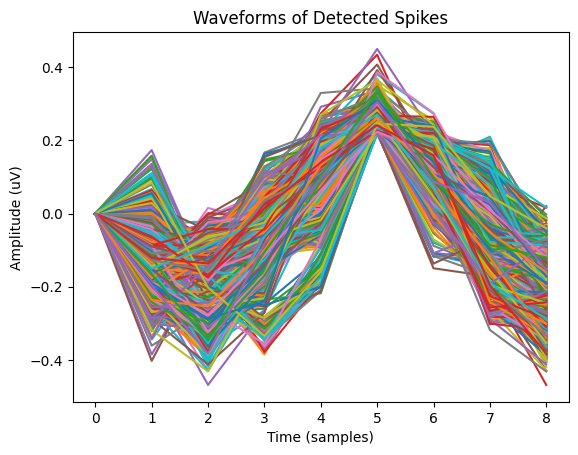

In [10]:
# Define high-pass filter parameters
fs = 2400  # Sampling rate
f_high = 300  # High-pass cutoff frequency
order = 7  # Filter order

# Design the filter coefficients
b, a = signal.butter(order, f_high / (fs / 2), btype='highpass')

# Apply the filter to the data
filtered_data = signal.filtfilt(b, a, voltage)

# Calculate the voltage threshold
sigma_n = np.median(np.abs(filtered_data)) / 0.6745
theta = 5 * sigma_n

# Find peaks in the data
diff_data = np.diff(filtered_data)
peaks = np.where((diff_data[:-1] > 0) & (diff_data[1:] < 0))[0] + 1

# Find spikes based on threshold
spikes = peaks[filtered_data[peaks] >= theta]

# Extract waveform for each spike
window_size = int(0.004 * fs)  # 2ms window
waveforms = np.zeros((len(spikes), window_size))
for i, s in enumerate(spikes):
    waveform_start = max(s - window_size // 2, 0)
    waveform_end = min(s + window_size // 2, len(filtered_data))
    waveform = filtered_data[waveform_start:waveform_end]
    if len(waveform) < window_size:
        waveform = np.concatenate((np.zeros(window_size - len(waveform)), waveform))
    waveforms[i, :] = waveform

# Plot waveforms
plt.figure()
plt.plot(waveforms.T)
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude (uV)')
plt.title('Waveforms of Detected Spikes')
plt.show()
waveforms = np.array(waveforms)

<font color="#F4BB44"><h3>Feature extraction using PCA</h3></font>

In [11]:
# Apply PCA on the waveform matrix
pca = PCA(n_components=8)
waveform_pca = pca.fit_transform(waveforms)
print(pca.singular_values_)

PC1 = waveform_pca[:, 0]
PC2 = waveform_pca[:, 1]
PC3 = waveform_pca[:, 2]
PC = [PC1, PC2, PC3]

pca_waveform = PC

pca_waveform = np.array(PC)
pca_waveform = np.transpose(pca_waveform)

[8.5529941  5.61293533 3.28665284 2.82368678 2.57025087 2.49363466
 1.84777402 0.72617792]


<font color="#F4BB44"><h3>Clustering using K-Means Clustering using PCA</h3></font>

In [12]:
# Perform K-Means clustering
n_clusters = 3  # Number of clusters
kmeans = KMeans(n_clusters=n_clusters, n_init="auto")
kmeans.fit(pca_waveform)  # Use PC1, PC2, and PC3 as features for clustering

# Get the cluster labels for each waveform
cluster_labels = kmeans.labels_

# Print the cluster labels
print("Cluster Labels:", cluster_labels)

Cluster Labels: [2 0 2 ... 0 2 0]


<font color="#F4BB44"><h3>Plot Scatter plot of #3 main component principle</h3></font>

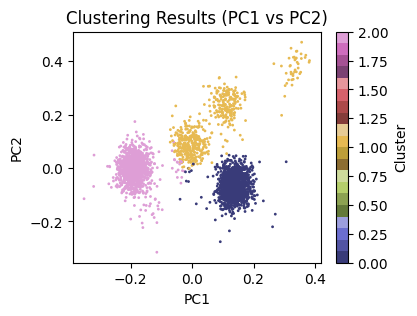

In [13]:
# Scatter plot for PC1 and PC2
plt.figure(figsize=(4, 3))
plt.scatter(PC1, PC2, c=cluster_labels, cmap='tab20b', s=1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering Results (PC1 vs PC2)')
plt.colorbar(label='Cluster')
plt.show()

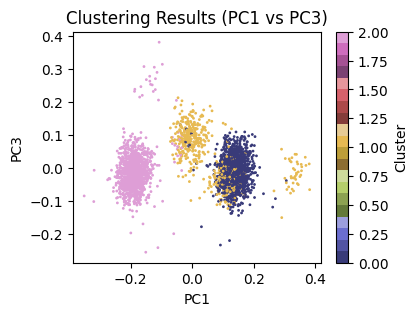

In [14]:
# Scatter plot for PC1 and PC3
plt.figure(figsize=(4, 3))
plt.scatter(PC1, PC3, c=cluster_labels, cmap='tab20b', s=1)
plt.xlabel('PC1')
plt.ylabel('PC3')
plt.title('Clustering Results (PC1 vs PC3)')
plt.colorbar(label='Cluster')
plt.show()

<font color="#F4BB44"><h3>Using silhouette_score to Find a K which was the best performance using PCA</h3></font>

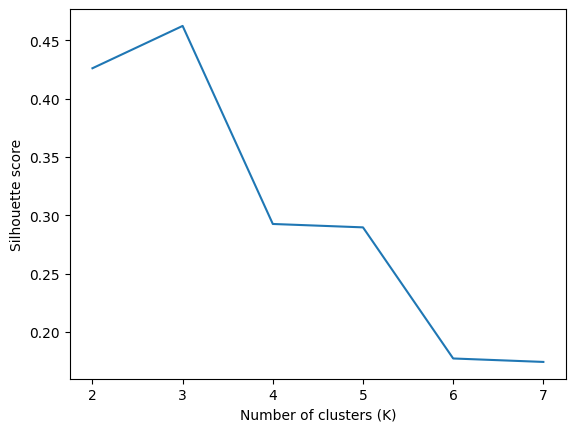

In [15]:
# Define a range of values for K
k_values = range(2, 8)

# Calculate silhouette scores for each value of K
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=10, n_init="auto")
    labels = kmeans.fit_predict(waveform_pca)
    score = silhouette_score(waveform_pca, labels)
    silhouette_scores.append(score)

# Plot the silhouette scores for each value of K
import matplotlib.pyplot as plt

plt.plot(k_values, silhouette_scores)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.show()


<font color="#F4BB44"><h3>Plot the Result of clustering with different K's using PCA</h3></font>

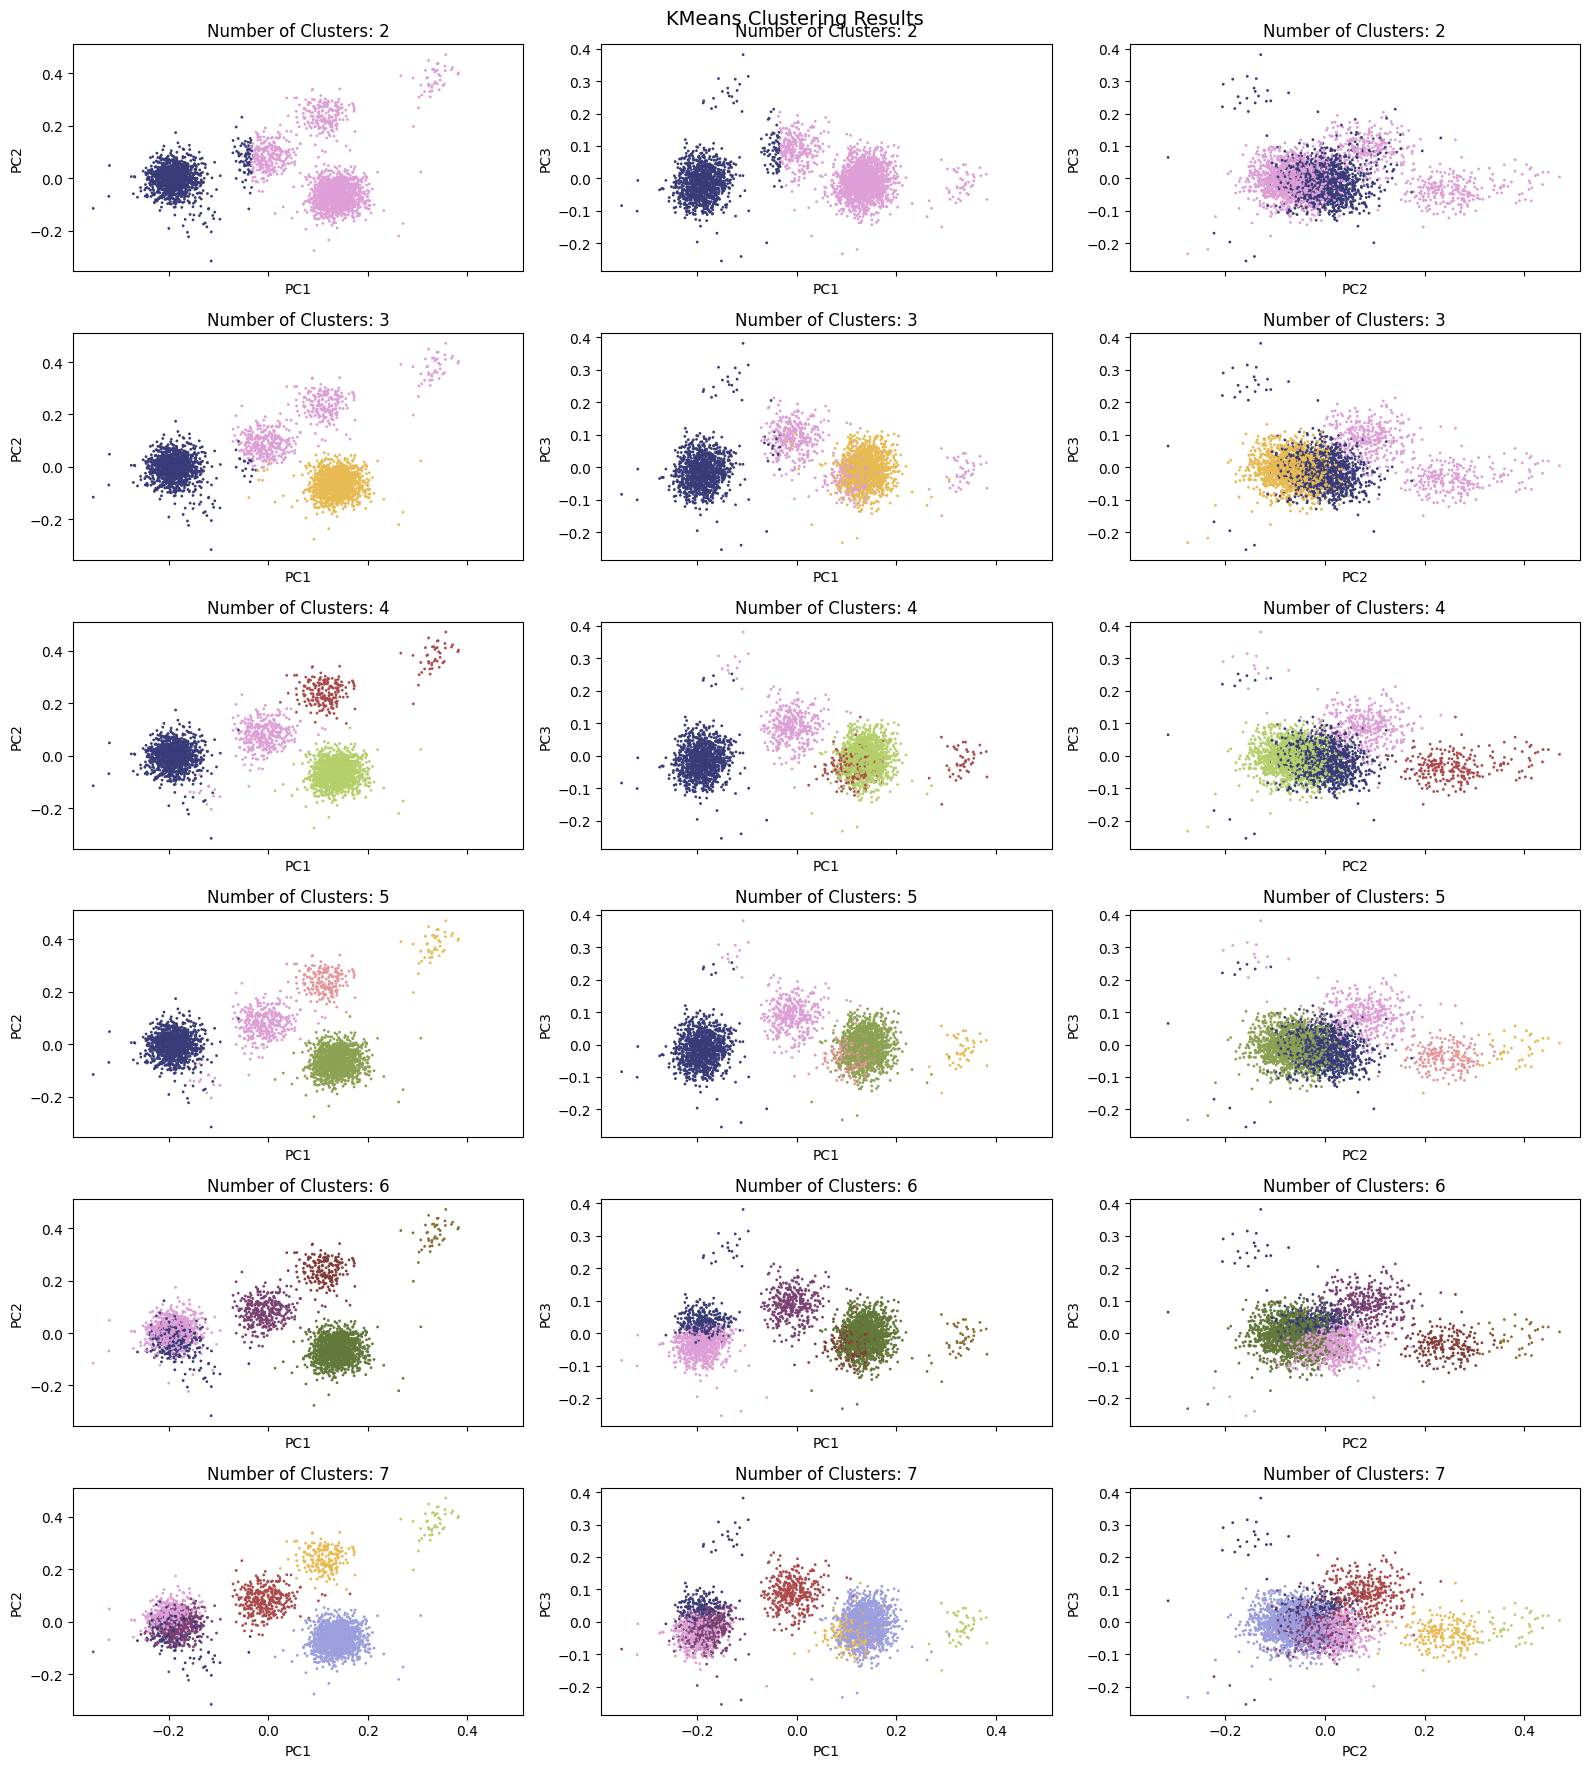

In [16]:
# Repeat part (k) and (l) with different values of K for the clustering algorithm
k = 8
k_values = range(2, k)
fig, axes = plt.subplots(k-2, 3, sharex=True, figsize=(4 * 4, (k-2) * 3))
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=k, n_init="auto").fit(waveform_pca)
    labels = kmeans.labels_
    axes[i-2, 0].scatter(waveform_pca[:,0], waveform_pca[:,1], c = labels, s=1, cmap='tab20b')
    axes[i-2, 0].set_title('Number of Clusters: ' + str(i))
    axes[i-2, 0].set_xlabel('PC1')
    axes[i-2, 0].set_ylabel('PC2')
    
    axes[i-2, 1].scatter(waveform_pca[:,0], waveform_pca[:,2], c = labels, s=1, cmap='tab20b')
    axes[i-2, 1].set_title('Number of Clusters: ' + str(i))
    axes[i-2, 1].set_xlabel('PC1')
    axes[i-2, 1].set_ylabel('PC3')
    
    axes[i-2, 2].scatter(waveform_pca[:,1], waveform_pca[:,2], c = labels, s=1, cmap='tab20b')
    axes[i-2, 2].set_title('Number of Clusters: ' + str(i))
    axes[i-2, 2].set_xlabel('PC2')
    axes[i-2, 2].set_ylabel('PC3')
    
# Add overall title and adjust layout
fig.suptitle('KMeans Clustering Results', fontsize=14)
fig.tight_layout()

<font color="#F4BB44"><h3>Compute performance metrics  of the K-means clustering by using PCA</h3></font>

In [17]:
# Compute performance metrics
time_window = 0.001  # +/- 1ms
true_positives = 0
false_positives = 0
false_negatives = 0

for spike_time in spike_idx:
    if np.any(np.abs(peaks - spike_time) <= time_window * fs):
        true_positives += 1
    else:
        false_negatives += 1

for spike_time in spikes:
    if np.all(np.abs(spike_time - spike_idx) > time_window * fs):
        false_positives += 1

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision: %.3f" % precision)
print("Recall: %.3f" % recall)
print("F1-Score: %.3f" % f1_score)


Precision: 0.772
Recall: 0.957
F1-Score: 0.855


<font color="#F4BB44"><h3>Filtering: Applying a Bandpass Filter Using New Threshold</h3></font>

[ 845516 2350824 3253884 3643715 3684329 3691450 3691456 4107918 4393995
 4403675]


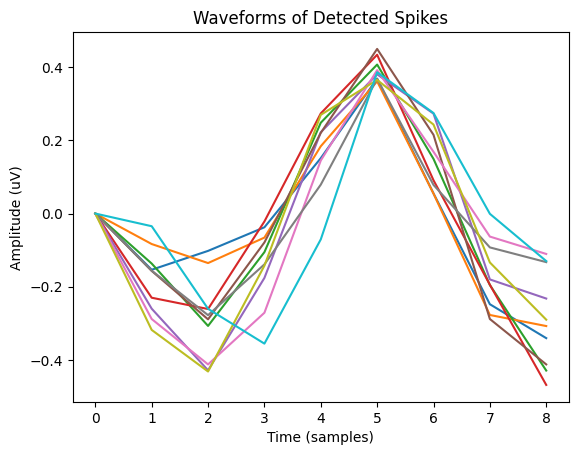

In [18]:
# extract the voltage amplitude data from the structure
voltage = data['all_data_with_noise_and_line'][0,:] 

# Define high-pass filter parameters
fs = 2400  # Sampling rate
f_high = 300  # High-pass cutoff frequency
order = 7  # Filter order

# Design the filter coefficients
b, a = signal.butter(order, f_high / (fs / 2), btype='highpass')

# Apply the filter to the data
filtered_data = signal.filtfilt(b, a, voltage)

# Find peaks in the data
diff_data = np.diff(filtered_data)
peaks = np.where((diff_data[:-1] > 0) & (diff_data[1:] < 0))[0] + 1

# Calculate the voltage threshold
new_theta = 0.8 * np.max(filtered_data)
p = filtered_data[peaks] >= new_theta

# Find spikes based on threshold
new_spikes = peaks[filtered_data[peaks] >= new_theta]
print(new_spikes)

# Extract waveform for each spike
window_size = int(0.004 * fs)  # 2ms window
new_waveforms = np.zeros((len(new_spikes), window_size))
for i, s in enumerate(new_spikes):
    new_waveform_start = max(s - window_size // 2, 0)
    new_waveform_end = min(s + window_size // 2, len(filtered_data))
    new_waveform = filtered_data[new_waveform_start:new_waveform_end]
    if len(new_waveform) < window_size:
        new_waveform = np.concatenate((np.zeros(window_size - len(new_waveform)), new_waveform))
    new_waveforms[i, :] = new_waveform

# Plot waveforms
plt.figure()
plt.plot(new_waveforms.T)
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude (uV)')
plt.title('Waveforms of Detected Spikes')
plt.show()
new_waveforms = np.array(new_waveforms)

<font color="#F4BB44"><h3>Using K-Means Clustering with New Threshold</h3></font>

In [19]:
# Apply PCA on the waveform matrix
pca = PCA(n_components=8)
new_waveform_pca = pca.fit_transform(new_waveforms)
print(pca.singular_values_)

new_PC1 = new_waveform_pca[:, 0]
new_PC2 = new_waveform_pca[:, 1]
new_PC3 = new_waveform_pca[:, 2]
new_PC = [new_PC1, new_PC2, new_PC3]

new_pca_waveform = new_PC

new_pca_waveform = np.array(new_PC)
new_pca_waveform = np.transpose(new_pca_waveform)

[0.62258675 0.45924231 0.25186375 0.14795406 0.0889995  0.07161821
 0.06647049 0.01176512]


In [20]:
# Perform K-Means clustering
n_clusters = 3  # Number of clusters
kmeans = KMeans(n_clusters=n_clusters, n_init="auto")
kmeans.fit(new_pca_waveform)  # Use PC1, PC2, and PC3 as features for clustering

# Get the cluster labels for each waveform
new_cluster_labels = kmeans.labels_

# Print the cluster labels
print("Cluster Labels:", new_cluster_labels)

Cluster Labels: [0 0 0 0 2 0 2 1 2 1]


<font color="#F4BB44"><h3>Scatter plot of #3 main component principle using new threshold</h3></font>

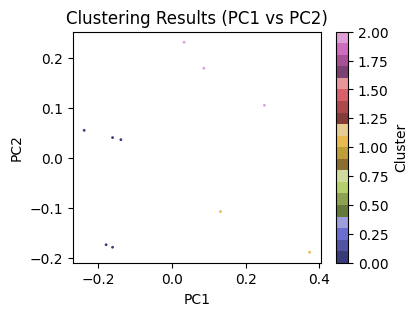

In [21]:
import matplotlib.pyplot as plt

# Scatter plot for PC1 and PC2
plt.figure(figsize=(4, 3))
plt.scatter(new_PC1, new_PC2, c=new_cluster_labels, cmap='tab20b', s=1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering Results (PC1 vs PC2)')
plt.colorbar(label='Cluster')
plt.show()

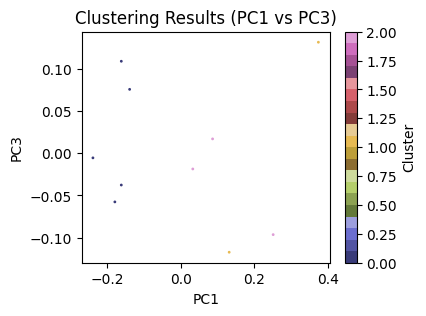

In [22]:
# Scatter plot for PC1 and PC3
plt.figure(figsize=(4, 3))
plt.scatter(new_PC1, new_PC3, c=new_cluster_labels, cmap='tab20b', s=1)
plt.xlabel('PC1')
plt.ylabel('PC3')
plt.title('Clustering Results (PC1 vs PC3)')
plt.colorbar(label='Cluster')
plt.show()

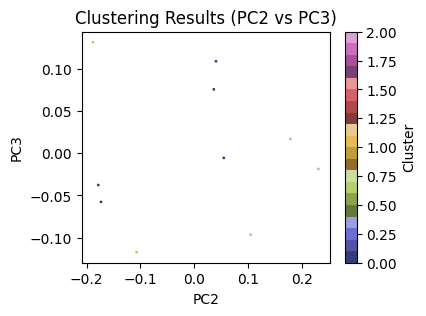

In [23]:
# Scatter plot for PC2 and PC3
plt.figure(figsize=(4, 3))
plt.scatter(new_PC2, new_PC3, c=new_cluster_labels, cmap='tab20b', s=1)
plt.xlabel('PC2')
plt.ylabel('PC3')
plt.title('Clustering Results (PC2 vs PC3)')
plt.colorbar(label='Cluster')
plt.show()

<font color="#F4BB44"><h3>Using silhouette_score to Find a K which was the best performance using new threshold</h3></font>

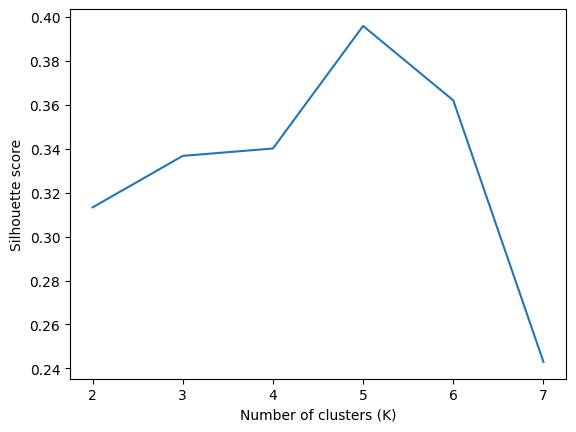

In [24]:
# Define a range of values for K
k_values = range(2, 8)

# Calculate silhouette scores for each value of K
new_silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=10, n_init="auto")
    new_labels = kmeans.fit_predict(new_waveform_pca)
    score = silhouette_score(new_waveform_pca, new_labels)
    new_silhouette_scores.append(score)

# Plot the silhouette scores for each value of K
plt.plot(k_values, new_silhouette_scores)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.show()


<font color="#F4BB44"><h3>Plot the Result of clustering with different K's with new threshold</h3></font>

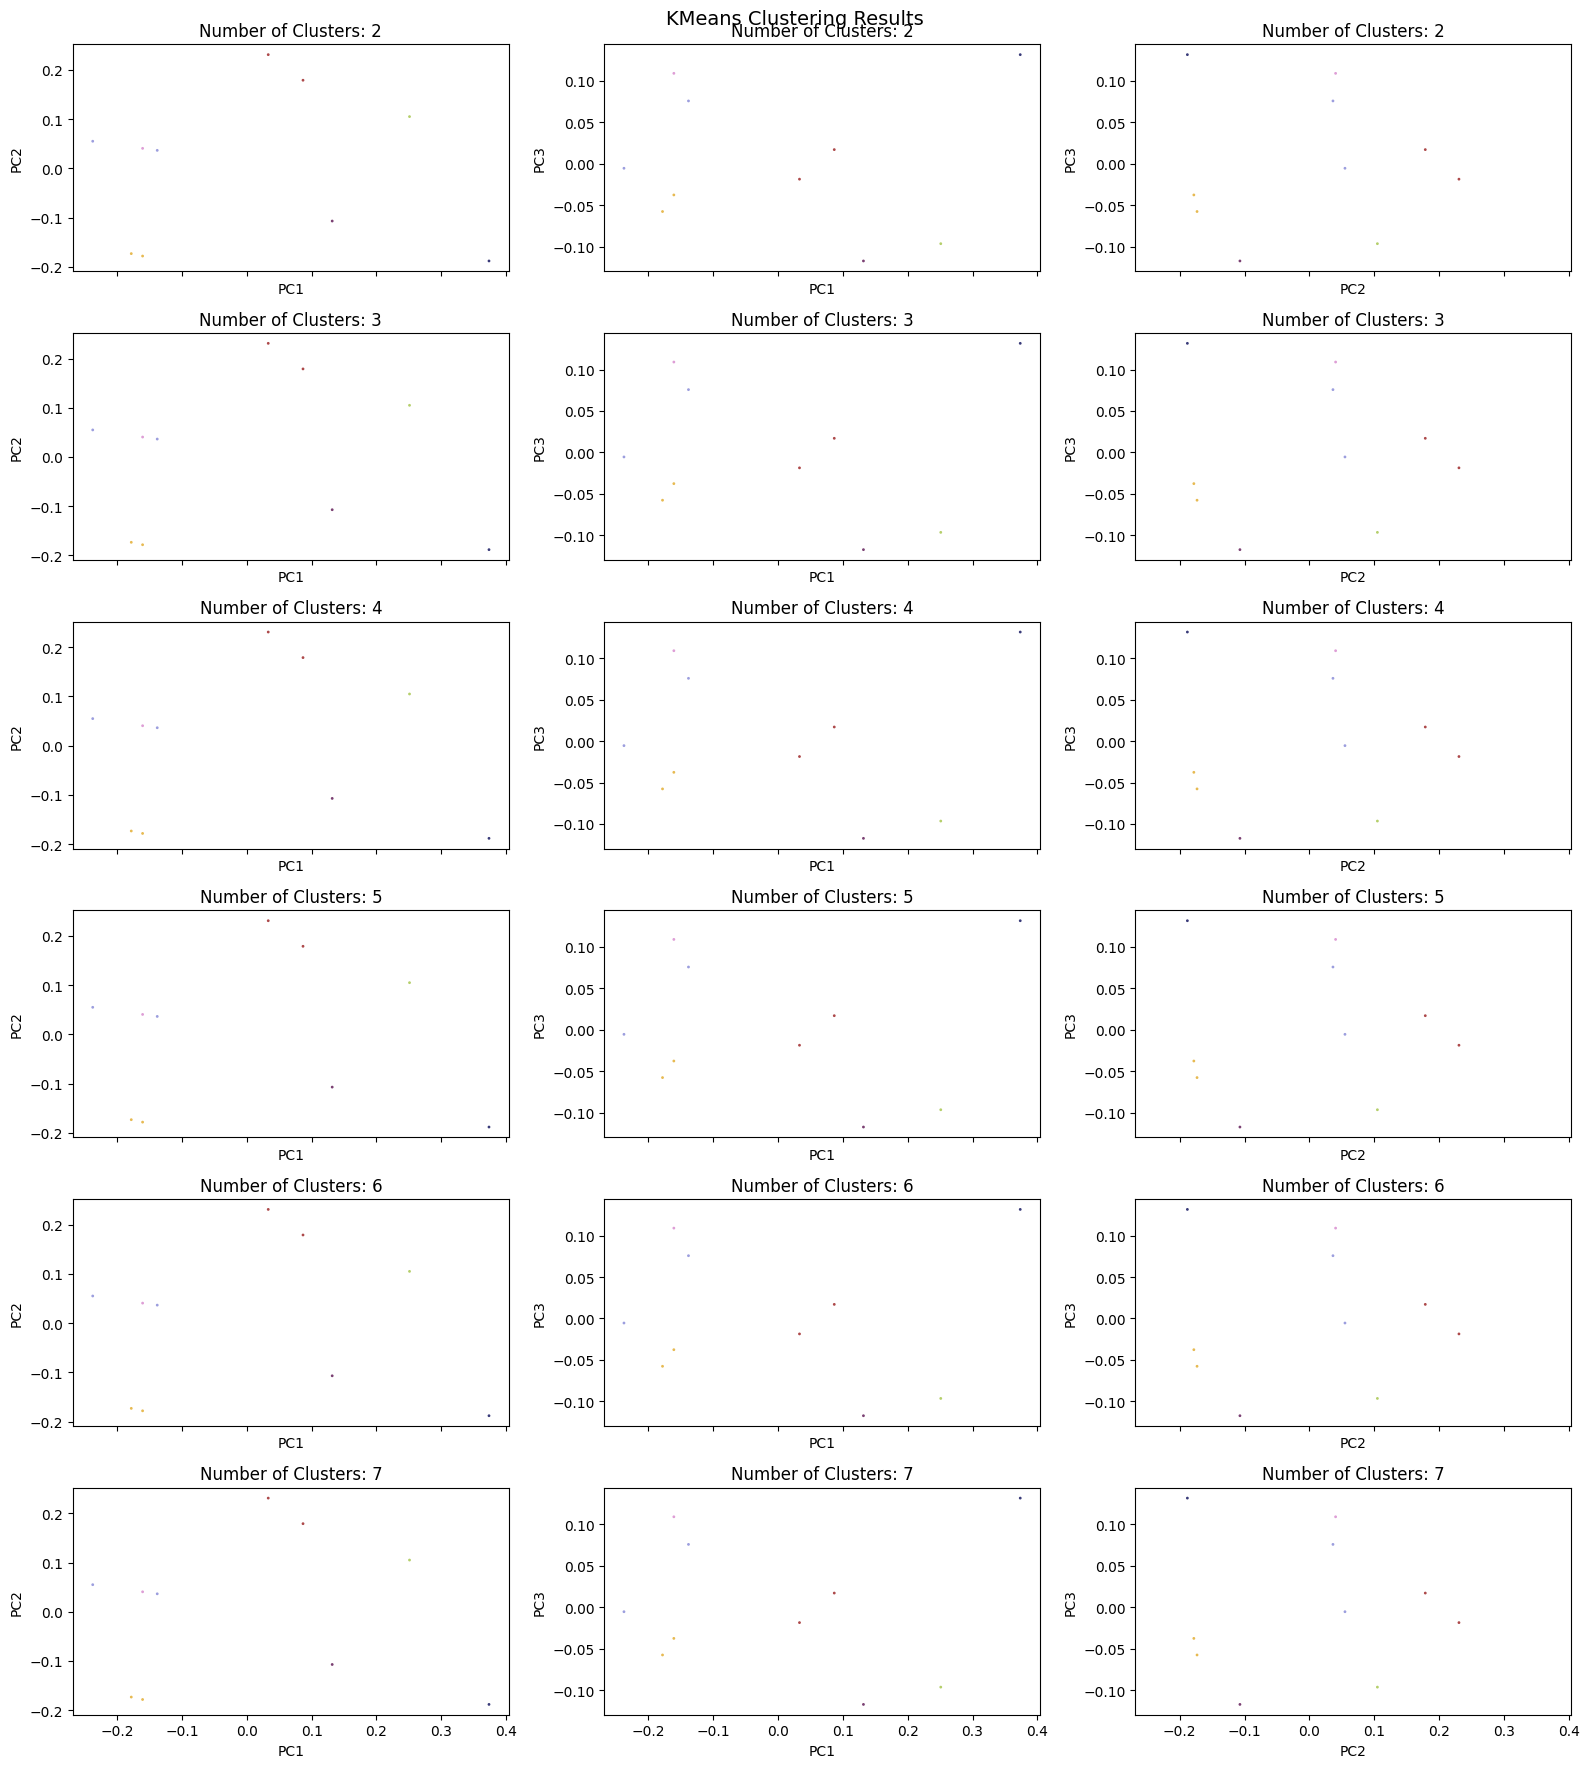

In [25]:
# Repeat part (k) and (l) with different values of K for the clustering algorithm
k = 8
k_values = range(2, k)
fig, axes = plt.subplots(k-2, 3, sharex=True, figsize=(4 * 4, (k-2) * 3))
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=k, n_init="auto").fit(new_waveform_pca)
    labels = kmeans.labels_
    axes[i-2, 0].scatter(new_waveform_pca[:,0], new_waveform_pca[:,1], c = new_labels, s=1, cmap='tab20b')
    axes[i-2, 0].set_title('Number of Clusters: ' + str(i))
    axes[i-2, 0].set_xlabel('PC1')
    axes[i-2, 0].set_ylabel('PC2')
    
    axes[i-2, 1].scatter(new_waveform_pca[:,0], new_waveform_pca[:,2], c = new_labels, s=1, cmap='tab20b')
    axes[i-2, 1].set_title('Number of Clusters: ' + str(i))
    axes[i-2, 1].set_xlabel('PC1')
    axes[i-2, 1].set_ylabel('PC3')
    
    axes[i-2, 2].scatter(new_waveform_pca[:,1], new_waveform_pca[:,2], c = new_labels, s=1, cmap='tab20b')
    axes[i-2, 2].set_title('Number of Clusters: ' + str(i))
    axes[i-2, 2].set_xlabel('PC2')
    axes[i-2, 2].set_ylabel('PC3')
    
# Add overall title and adjust layout
fig.suptitle('KMeans Clustering Results', fontsize=14)
fig.tight_layout()

<font color="#F4BB44"><h3>Compute performance metrics of the K-means clustering for new threshold</h3></font>

In [26]:
# Compute performance metrics
time_window = 0.001  # +/- 1ms
true_positives = 0
false_positives = 0
false_negatives = 0

for spike_time in spike_idx:
    if np.any(np.abs(peaks - spike_time) <= time_window * fs):
        true_positives += 1
    else:
        false_negatives += 1

for spike_time in new_spikes:
    if np.all(np.abs(spike_time - spike_idx) > time_window * fs):
        false_positives += 1

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision: %.3f" % precision)
print("Recall: %.3f" % recall)
print("F1-Score: %.3f" % f1_score)


Precision: 0.999
Recall: 0.957
F1-Score: 0.978


<font color="#F4BB44"><h3>Feature extraction and Dimension Reduction Using t-SNE</h3></font>

In [27]:
# Apply t-SNE to reduce dimensionality
tsne = TSNE(n_components=3, random_state=0)
tsne_feature = tsne.fit_transform(waveforms)

In [28]:
tsne_1 = tsne_feature[:, 0]
tsne_2 = tsne_feature[:, 1]
tsne_3 = tsne_feature[:, 2]
tsne_features = [tsne_1, tsne_2, tsne_3]

tsne_features = np.array(tsne_features)
tsne_features = np.transpose(tsne_features)

<font color="#F4BB44"><h3>Using silhouette_score to Find a K which was the best performance for t-SNE algorithm</h3></font>

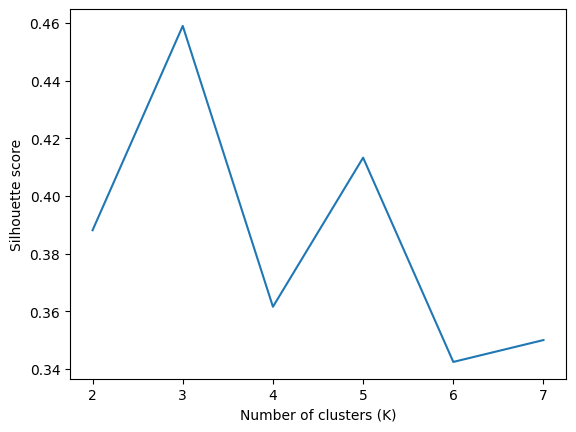

In [29]:
# Define a range of values for K
k_values = range(2, 8)

# Calculate silhouette scores for each value of K
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=10, n_init="auto")
    labels = kmeans.fit_predict(tsne_features)
    score = silhouette_score(tsne_features, labels)
    silhouette_scores.append(score)

# Plot the silhouette scores for each value of K
plt.plot(k_values, silhouette_scores)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.show()


<font color="#F4BB44"><h3>Plot the Result of clustering with different K's using t-SNE algorithm</h3></font>

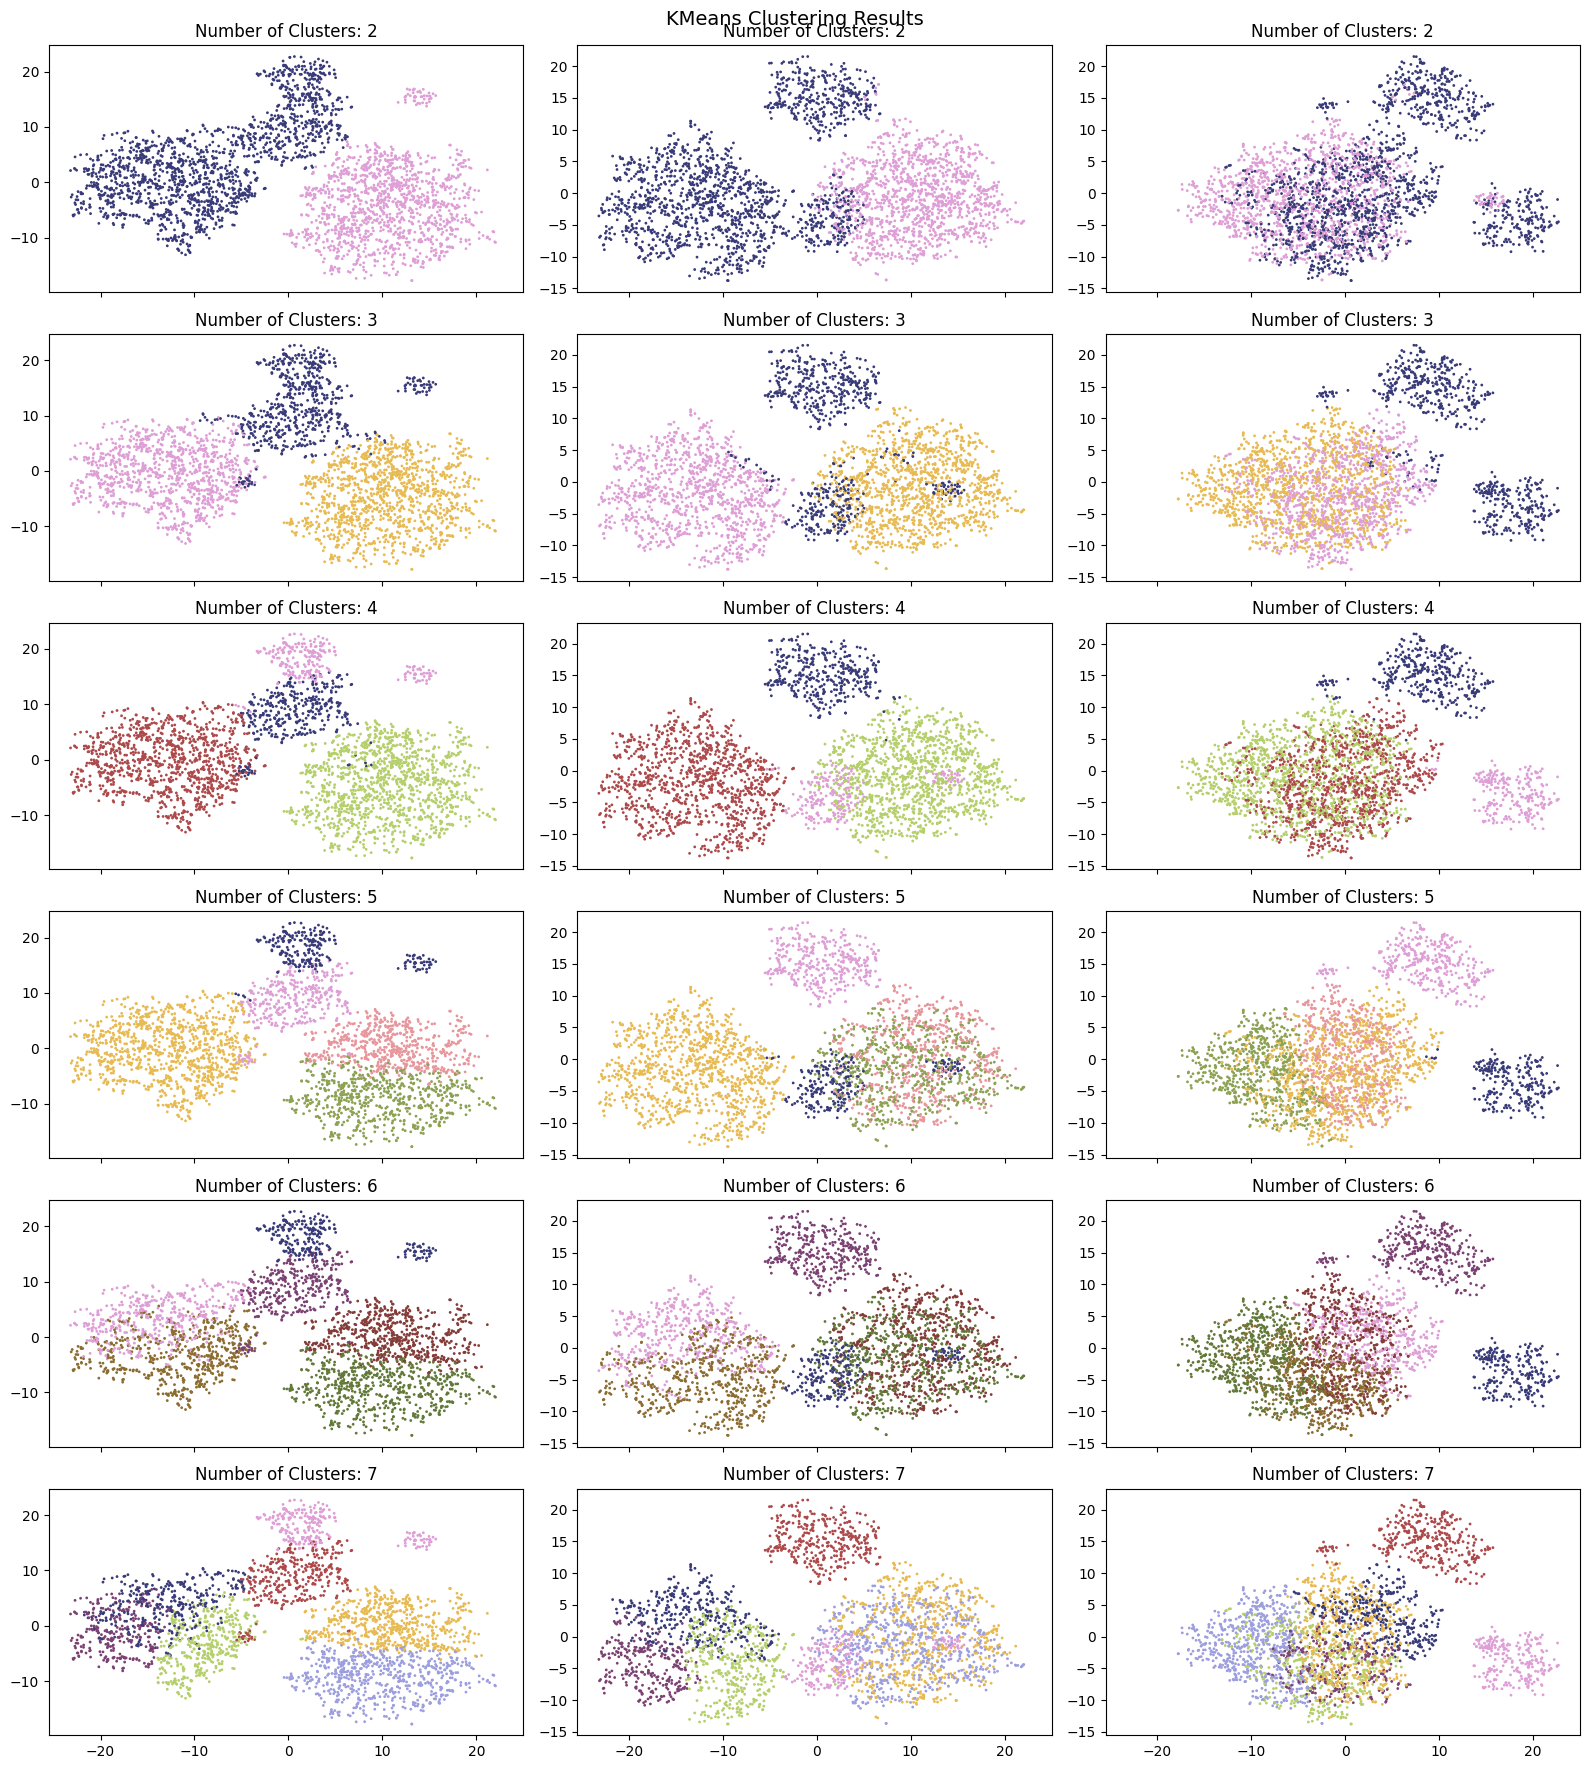

In [30]:
# Repeat part (k) and (l) with different values of K for the clustering algorithm
k = 8
k_values = range(2, k)
fig, axes = plt.subplots(k-2, 3, sharex=True, figsize=(4 * 4, (k-2) * 3))
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=k, n_init="auto").fit(tsne_features)
    labels = kmeans.labels_
    axes[i-2, 0].scatter(tsne_feature[:,0], tsne_features[:,1], c = labels, s=1, cmap='tab20b')
    axes[i-2, 0].set_title('Number of Clusters: ' + str(i))
    
    axes[i-2, 1].scatter(tsne_feature[:,0], tsne_features[:,2], c = labels, s=1, cmap='tab20b')
    axes[i-2, 1].set_title('Number of Clusters: ' + str(i))

    axes[i-2, 2].scatter(tsne_feature[:,1], tsne_features[:,2], c = labels, s=1, cmap='tab20b')
    axes[i-2, 2].set_title('Number of Clusters: ' + str(i))

    
# Add overall title and adjust layout
fig.suptitle('KMeans Clustering Results', fontsize=14)
fig.tight_layout()